## Анализ зависимости суммы операции и типа операции

In [1]:

from pyspark.sql.functions import first, sum, col, max, min,avg
from pyspark.sql import functions as F
from pyspark.sql import SparkSession
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql.functions import col, desc
import json
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# создание spark-сессии
spark =SparkSession.builder \
    .appName("analysis") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "2g") \
    .config("spark.sql.shuffle.partitions", "4") \
    .config("spark.memory.offHeap.enabled", "true") \
    .config("spark.memory.offHeap.size", "1g") \
    .getOrCreate()

## ANALYTICS POSTPROCESS

In [3]:
train_path = ["../datasets/joined/train_data.parquet","../datasets/joined/valid_data.parquet"]

df = spark.read.parquet(*train_path)


## столбики

In [4]:
df.dtypes

[('customer_id', 'bigint'),
 ('event_id', 'bigint'),
 ('event_type_nm', 'int'),
 ('event_desc', 'int'),
 ('channel_indicator_type', 'tinyint'),
 ('channel_indicator_sub_type', 'tinyint'),
 ('operaton_amt', 'double'),
 ('currency_iso_cd', 'tinyint'),
 ('mcc_code', 'string'),
 ('pos_cd', 'int'),
 ('browser_language', 'tinyint'),
 ('battery', 'int'),
 ('device_system_version', 'tinyint'),
 ('developer_tools', 'tinyint'),
 ('phone_voip_call_state', 'tinyint'),
 ('web_rdp_connection', 'tinyint'),
 ('compromised', 'int'),
 ('target', 'int'),
 ('os_category', 'tinyint'),
 ('tz_category', 'tinyint'),
 ('language_category', 'tinyint'),
 ('operaton_amt_is_missing', 'tinyint'),
 ('operaton_amt_log', 'double'),
 ('hour', 'tinyint'),
 ('month', 'tinyint'),
 ('day_of_week', 'tinyint'),
 ('is_night', 'tinyint'),
 ('mean_operation', 'double'),
 ('median_operation', 'double'),
 ('user_activity', 'bigint')]

In [10]:
with open('../datasets/joined/columns_list.json', 'r') as f:
    features = json.load(f)
    
all_cols = features['all']
cat_cols = features['cat']
num_cols = list(set(all_cols) - set(cat_cols))

c:\antifraud_hak\antifraud_hak\.venv\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\antifraud_hak\antifraud_hak\.venv\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\antifraud_hak\antifraud_hak\.venv\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


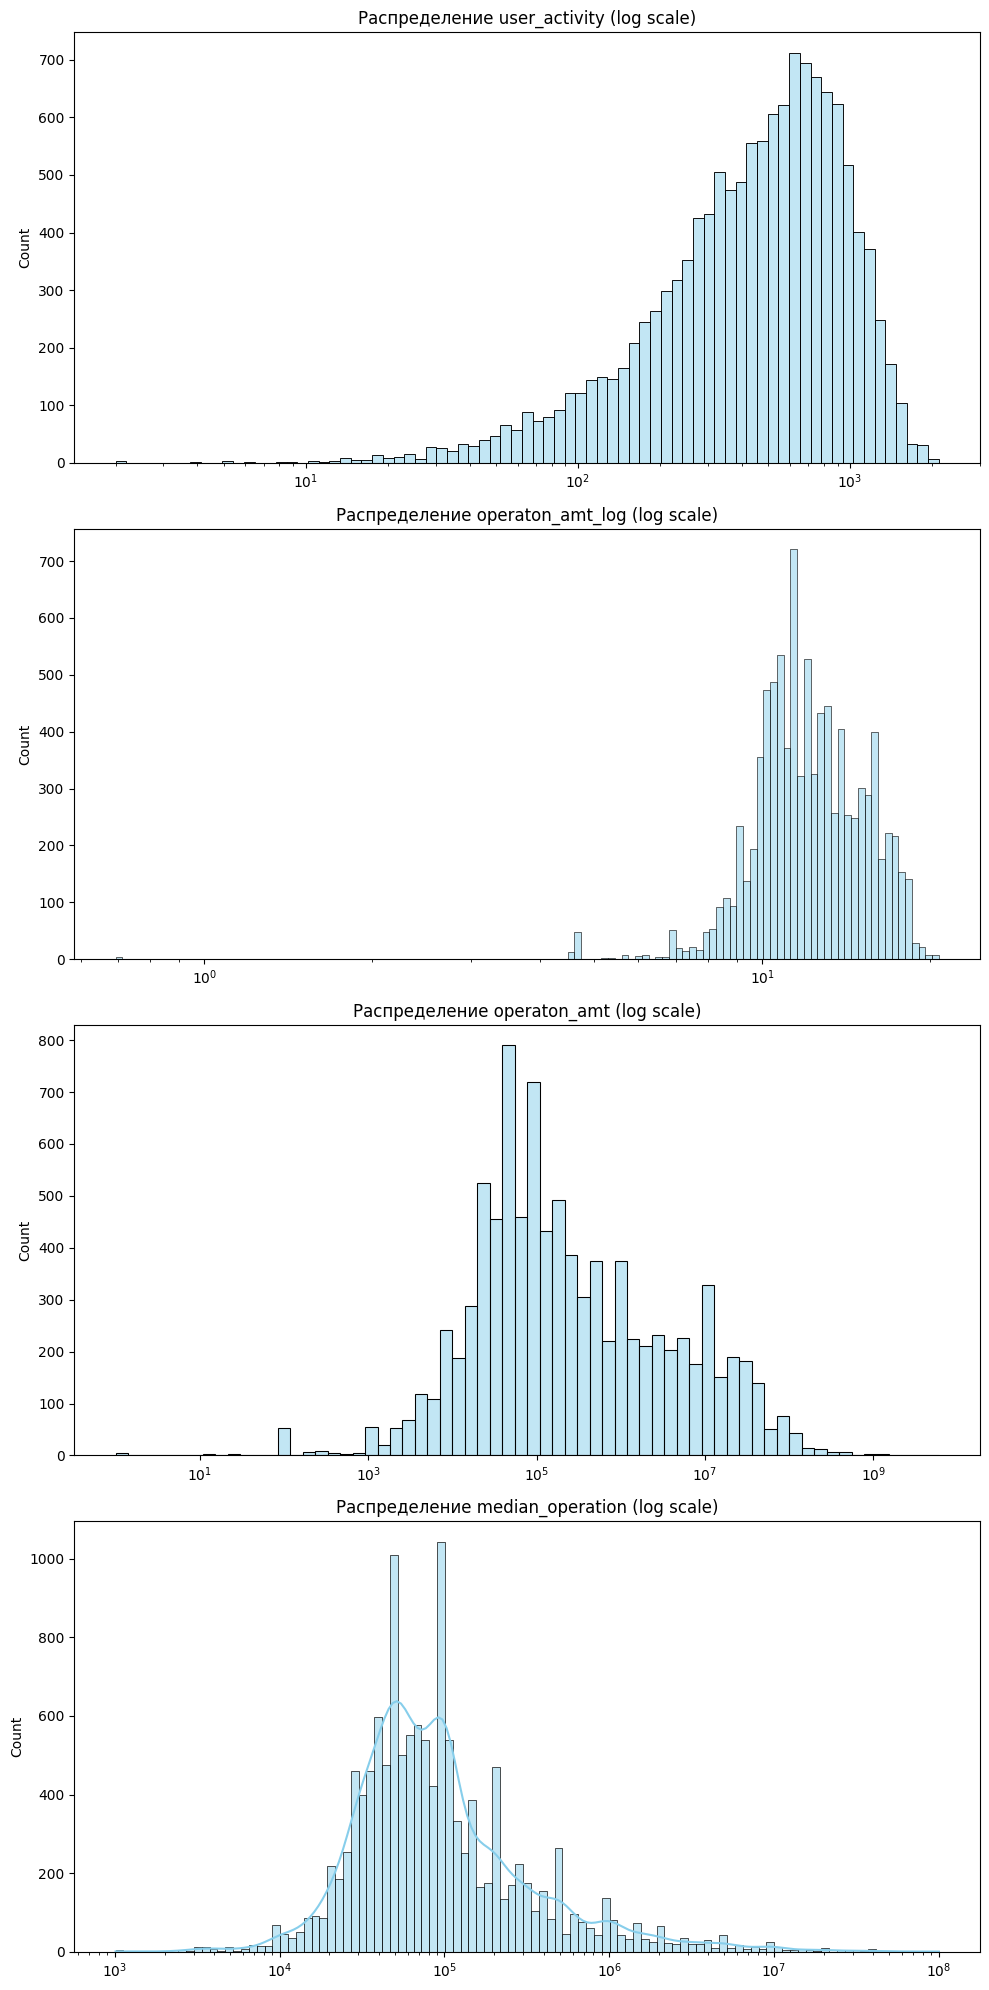

In [11]:

# 1. Считаем количество графиков
n_cols = len(num_cols)

# 2. Создаем "сетку" из графиков: n_cols строк и 1 столбец
# figsize=(ширина, высота), высоту увеличиваем пропорционально кол-ву графиков
fig, axes = plt.subplots(nrows=n_cols, ncols=1, figsize=(10, 5 * n_cols))

# Если график всего один, axes будет не списком, а объектом. Исправляем это:
if n_cols == 1:
    axes = [axes]

for i, col_name in enumerate(num_cols):
    # Берем 10% данных
    pdf = df.select(col_name).sample(False, 0.1).toPandas()
    
    # Рисуем на конкретной оси axes[i]
    sns.histplot(data=pdf, x=col_name, kde=True, log_scale=True, 
                 color="skyblue", ax=axes[i])
    
    axes[i].set_title(f"Распределение {col_name} (log scale)")
    axes[i].set_xlabel("") # Убираем лишние подписи осей, если нужно

# Автоматически подправляем отступы, чтобы заголовки не налезали на графики
plt.tight_layout()
plt.show()
